# cGAN으로 생성 제어하기

In [1]:
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torchvision.utils import save_image
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 하이퍼파라미터
EPOCHS = 300 # 총 데이터 반복 훈련 횟수
BATCH_SIZE = 100 # 미니배치 당 연산할 데이터 샘플 개수
USE_CUDA = torch.cuda.is_available() # 하드웨어 가속기 GPU 연산 가능 여부 검사
DEVICE = torch.device("cuda" if USE_CUDA else "cpu") # 실제 연산 처리를 담당할 하드웨어 장치 지정
print("Using Device:", DEVICE) # 지정된 연산 장치 상태 확인용 출력

Using Device: cuda


In [3]:
# Fashion MNIST 데이터셋
trainset = datasets.FashionMNIST( # 의류 이미지 세트 다운로드 지시
    './.data',
    train=True,
    download=True,
    transform=transforms.Compose([
       transforms.ToTensor(),
       transforms.Normalize((0.5,), (0.5,))
    ])
)
train_loader = torch.utils.data.DataLoader( # 배치 단위로 무작위 데이터를 주입하는 데이터 셔플러
    dataset     = trainset,
    batch_size  = BATCH_SIZE,
    shuffle     = True
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.98MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 29.0MB/s]


In [4]:
# 생성자 (Generator)
class Generator(nn.Module):
    def __init__(self):
        super().__init__() # 부모 nn.Module 속성 계승 호출
        
        self.embed = nn.Embedding(10, 10) # 10개 범주 레이블을 10차원의 연속 벡터 공간으로 변환
        
        self.model = nn.Sequential( # 연산 레이어 시퀀스 정의
            nn.Linear(110, 256), # 입력: 무작위 잠재 코드(100) + 조건 임베딩(10)
            nn.LeakyReLU(0.2, inplace=True), # 기울기 역전파 차단 방지 목적 함수
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True), # 기울기 역전파 차단 방지 목적 함수
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True), # 기울기 역전파 차단 방지 목적 함수
            nn.Linear(1024, 784),
            nn.Tanh()
        )
    
    def forward(self, z, labels):
        c = self.embed(labels)
        x = torch.cat([z, c], 1)
        return self.model(x)

In [ ]:
# 판별자 (Discriminator)
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__() # 부모 nn.Module 속성 초기화 호출
        
        self.embed = nn.Embedding(10, 10) # 레이블 조건을 조건부 매핑 공간으로 결합 처리
        
        self.model = nn.Sequential(
            nn.Linear(794, 1024),
            nn.LeakyReLU(0.2, inplace=True), # 기울기 역전파 차단 방지 목적 함수
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True), # 기울기 역전파 차단 방지 목적 함수
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True), # 기울기 역전파 차단 방지 목적 함수
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid() # 확률 판단이 가능하도록 0~1 수치 제어
        )
    
    def forward(self, x, labels): # 판별 망 검증 전방 연산
        c = self.embed(labels) # 해당 정수 레이블 조건 임베딩 추출
        x = torch.cat([x, c], 1) # 원본 혹은 가짜 이미지 뒤에 조건 정보를 이어 붙임
        return self.model(x) # 최종 확률 판정값 반환

In [6]:
# 모델 인스턴스를 만들고 모델의 가중치를 지정한 장치로 보내기
D = Discriminator().to(DEVICE) # 판별자 객체를 그래픽 카드 메모리에 배정
G = Generator().to(DEVICE) # 생성자 객체를 그래픽 카드 메모리에 배정

# 이진 교차 엔트로피 함수와
# 생성자와 판별자를 최적화할 Adam 모듈
criterion = nn.BCELoss() # 진짜와 가짜를 판독할 비용 함수 세팅
d_optimizer = optim.Adam(D.parameters(), lr =0.0002) # 판별 성능 조율용 최적화 모델
g_optimizer = optim.Adam(G.parameters(), lr =0.0002) # 생성 기술 개선용 최적화 모델

In [7]:
total_step = len(train_loader)
for epoch in range(EPOCHS): # 총 루프 카운트 수행
    for i, (images, labels) in enumerate(train_loader): # 데이터로더로부터 이미지 정보와 레이블 수신
        images = images.reshape(BATCH_SIZE, -1).to(DEVICE) # 전방 연산 수행 전 벡터로 데이터 직렬화
        
        # '진짜'와 '가짜' 레이블 생성
        real_labels = torch.ones(BATCH_SIZE, 1).to(DEVICE) # 정답 비교군 1 할당
        fake_labels = torch.zeros(BATCH_SIZE, 1).to(DEVICE) # 정답 비교군 0 할당

        # 판별자가 진짜 이미지를 진짜로 인식하는 오차 계산 (데이터셋 레이블 입력)
        labels = labels.to(DEVICE) # 해당 레이블 데이터 장치 전송
        outputs = D(images, labels) # 이미지와 정답 레이블 조건 전달
        d_loss_real = criterion(outputs, real_labels) # 진짜 예측값과 목표 결과치 대조 오차 도출
        real_score = outputs # 진짜 인지 스코어 기록
    
        # 무작위 텐서와 무작위 레이블을 생성자에 입력해 가짜 이미지 생성
        z = torch.randn(BATCH_SIZE, 100).to(DEVICE) # 잠재 무작위 노이즈 분포 추출
        g_label = torch.randint(0, 10, (BATCH_SIZE,)).to(DEVICE)
        fake_images = G(z, g_label) # 의도한 레이블 가이드라인을 부여하여 이미지 빌드
        
        # 판별자가 가짜 이미지를 가짜로 인식하는 오차 계산
        outputs = D(fake_images, g_label) # 완성품 이미지와 원본 타겟 정보 검증 요청
        d_loss_fake = criterion(outputs, fake_labels) # 위조품 결과에 대한 에러율 환
        fake_score = outputs # 가짜 인지 스코어 기록
        
        # 진짜와 가짜 이미지를 갖고 낸 오차를 더해서 판별자의 오차 계산
        d_loss = d_loss_real + d_loss_fake # 두 오차 요인을 통합하여 총체적 판단 오차 정립
        
        # 역전파 알고리즘으로 판별자 모델의 학습을 진행
        d_optimizer.zero_grad() # 판별 망에 잔존하는 연산 값 초기화
        g_optimizer.zero_grad() # 이전 스텝 생성 경사 연산 버퍼 비우기
        d_loss.backward() # 누적 손실 기반 경사하강 역전파 가동
        d_optimizer.step() # 판별 계층 내부 가중치 정보 수정
        
        # 생성자가 판별자를 속였는지에 대한 오차 계산(무작위 레이블 입력)
        fake_images = G(z, g_label) # 신규 이미지 연산 재생성
        outputs = D(fake_images, g_label) # 생성된 결과물을 다시 판별자에 투입
        g_loss = criterion(outputs, real_labels) # 결과물이 진짜 데이터인 것처럼 속이기 위한 목적 오차 환산

        # 역전파 알고리즘으로 생성자 모델의 학습을 진행
        d_optimizer.zero_grad() # 판별 망에 잔존하는 연산 값 초기화
        g_optimizer.zero_grad() # 이전 스텝 생성 경사 연산 버퍼 비우기
        g_loss.backward() # 타겟 기만 알고리즘 역전파 수행
        g_optimizer.step() # 생성자 네트워크 매개변수 가중치 보정
        
    # 각 에포크 종료 타이밍 로그 기록
    print('이폭 [{}/{}] d_loss:{:.4f} g_loss: {:.4f} D(x):{:.2f} D(G(z)):{:.2f}'
          .format(epoch,
                  EPOCHS,
                  d_loss.item(),
                  g_loss.item(),
                  real_score.mean().item(),
                  fake_score.mean().item()))

이폭 [0/300] d_loss:0.4831 g_loss: 6.3467 D(x):0.83 D(G(z)):0.07
이폭 [1/300] d_loss:0.3896 g_loss: 3.6797 D(x):0.90 D(G(z)):0.16
이폭 [2/300] d_loss:0.3919 g_loss: 4.1669 D(x):0.91 D(G(z)):0.16
이폭 [3/300] d_loss:0.5190 g_loss: 3.6486 D(x):0.84 D(G(z)):0.14
이폭 [4/300] d_loss:0.5851 g_loss: 2.1264 D(x):0.88 D(G(z)):0.27
이폭 [5/300] d_loss:0.7173 g_loss: 2.6693 D(x):0.75 D(G(z)):0.20
이폭 [6/300] d_loss:0.5110 g_loss: 2.3341 D(x):0.89 D(G(z)):0.21
이폭 [7/300] d_loss:0.7320 g_loss: 1.6717 D(x):0.83 D(G(z)):0.29
이폭 [8/300] d_loss:0.7701 g_loss: 2.5282 D(x):0.78 D(G(z)):0.26
이폭 [9/300] d_loss:0.9848 g_loss: 1.4612 D(x):0.75 D(G(z)):0.35
이폭 [10/300] d_loss:0.9292 g_loss: 1.6579 D(x):0.70 D(G(z)):0.31
이폭 [11/300] d_loss:1.0980 g_loss: 1.3953 D(x):0.71 D(G(z)):0.37
이폭 [12/300] d_loss:1.0642 g_loss: 1.3902 D(x):0.59 D(G(z)):0.30
이폭 [13/300] d_loss:1.0620 g_loss: 1.5224 D(x):0.69 D(G(z)):0.36
이폭 [14/300] d_loss:1.0274 g_loss: 1.4690 D(x):0.73 D(G(z)):0.35
이폭 [15/300] d_loss:0.9784 g_loss: 1.1761 D(x):0.70

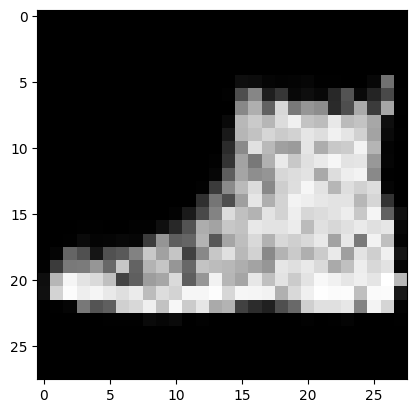

In [8]:
# 만들고 싶은 아이템 생성하고 시각화하기
item_number = 9 # 아이템 번호
z = torch.randn(1, 100).to(DEVICE) # 배치 크기 1
g_label = torch.full((1,), item_number, dtype=torch.long).to(DEVICE)
sample_images = G(z, g_label)

sample_images_img = np.reshape(sample_images.data.cpu().numpy()
                               [0],(28, 28))
plt.imshow(sample_images_img, cmap = 'gray')
plt.show()